# Figures 
Notebook for creating figures

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ground_truth_df = pd.read_table('../data/raw/ground_truth.tsv')
ground_truth_df.head()

,term,rigidity,identity,own_identity,unity,dependence
0,Entity,+R,-I,-O,-U,-D
1,Location,+R,+I,+O,-U,-D
2,AmountOfMatter,+R,+I,+O,~U,-D
3,Red,-R,-I,-O,-U,-D
4,Agent,~R,-I,-O,-U,+D


In [3]:
melt_df = pd.melt(
    ground_truth_df,
    id_vars=['term'], 
    value_vars=['rigidity', 'identity', 'own_identity', 'unity', 'dependence'],
    var_name='property_name',
    value_name='property'
)
melt_df

,term,property_name,property
0,Entity,rigidity,+R
1,Location,rigidity,+R
2,AmountOfMatter,rigidity,+R
3,Red,rigidity,-R
4,Agent,rigidity,~R
...,...,...,...
105,RedApple,dependence,-D
106,Caterpillar,dependence,-D
107,Butterfly,dependence,-D
108,Person,dependence,-D


In [4]:
plot_df = melt_df[['property']].value_counts().to_frame()
plot_df

,count
property,
+I,19
-D,17
+R,15
+O,13
+U,13
-O,9
-U,7
~R,6
+D,5


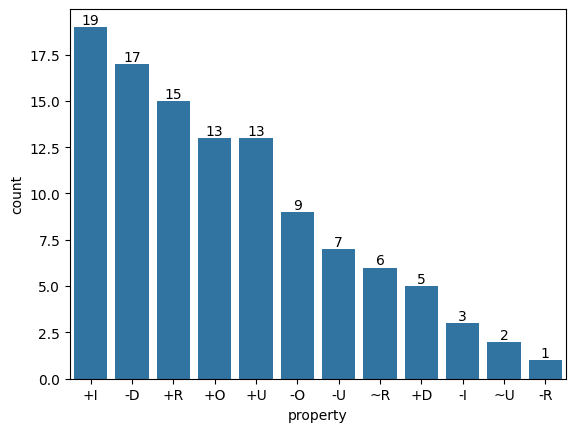

In [5]:
ax = sns.barplot(plot_df, x='property', y='count', estimator="sum")
ax.bar_label(ax.containers[0]) # Add the value labels on top of the bars
plt.show()